<a href="https://colab.research.google.com/github/BlockchainDlamini/COS781_Data_Mining_Project/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pwd

'/content'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd ./drive/MyDrive/COS711/assoc_rule_mining

/content/drive/MyDrive/COS711/assoc_rule_mining


In [4]:
%pwd

'/content/drive/MyDrive/COS711/assoc_rule_mining'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the test dataset
file_path = './algebra_2005_2006_master.txt'
df = pd.read_csv(file_path, sep='\t')

CHAR_FILLER = 90

In [6]:
def inspect_data(df):
    print(f"Dataset Shape: {df.shape}")
    print("-" * CHAR_FILLER)
    print("\n")
    print("Columns:")
    print(list(df.columns))
    print("-" * CHAR_FILLER)
    print("\n")
    print("Info:")
    print(df.info())
    print("-" * CHAR_FILLER)
    print("\n")
    print("Statistical measures:")
    print(df.describe())
    print("-" * CHAR_FILLER)
    print("\n")
    print("First few rows:")
    print(df.head())
    print("-" * CHAR_FILLER)
    print("\n")
    print("Last few rows")
    print(df.tail())

inspect_data(df)

Dataset Shape: (3967, 19)
------------------------------------------------------------------------------------------


Columns:
['Row', 'Anon Student Id', 'Problem Hierarchy', 'Problem Name', 'Problem View', 'Step Name', 'Step Start Time', 'First Transaction Time', 'Correct Transaction Time', 'Step End Time', 'Step Duration (sec)', 'Correct Step Duration (sec)', 'Error Step Duration (sec)', 'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects', 'KC(Default)', 'Opportunity(Default)']
------------------------------------------------------------------------------------------


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3967 entries, 0 to 3966
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Row                          3967 non-null   int64  
 1   Anon Student Id              3967 non-null   object 
 2   Problem Hierarchy            3967 non-null   object 
 3   Proble

In [7]:
# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# sns.set_style("whitegrid")

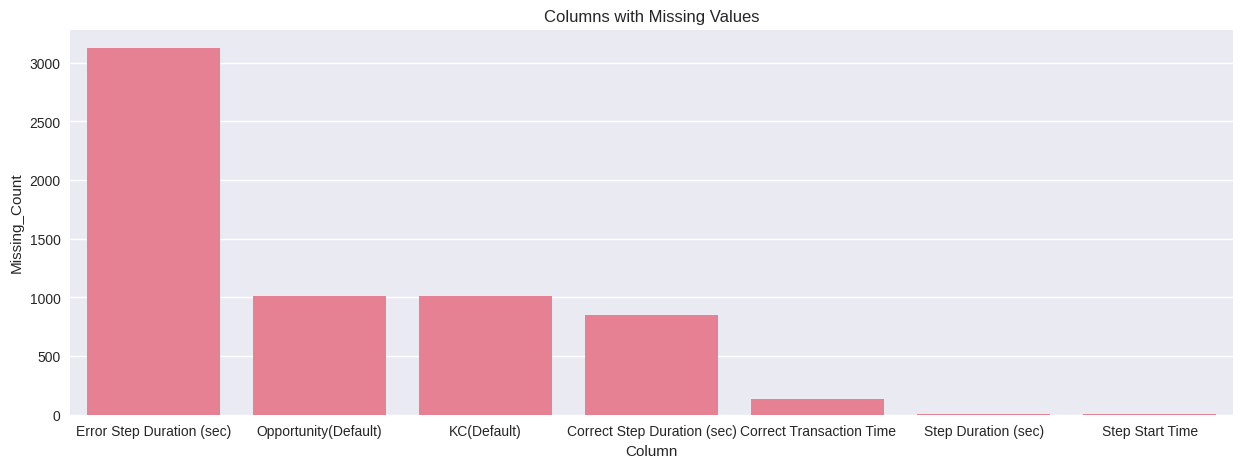

In [47]:
def analyze_missing_values(df):
    missing_data = df.isna().sum()
    missing_percent = (missing_data / len(df)) * 100

    missing_df = pd.DataFrame({
        'Column': missing_data.index,
        'Missing_Count': missing_data.values,
        'Missing_Percentage': missing_percent.values
    }).sort_values(by="Missing_Count",ascending=False)

    # Filter only columns with missing values
    missing_df = missing_df[missing_df['Missing_Count'] > 0]

    if len(missing_df) == 0:
        print("-" * 40)
        print("\nNo missing values found!")
    else:
        # Visualize missing values
        ax = sns.barplot(data=missing_df, ax=axs, x='Column', y='Missing_Count')
        ax.set(title="Columns with Missing Values")

    return missing_df

fig, axs = plt.subplots(1,1, figsize=(15, 5))
fig.subplots_adjust()

missing_summary = analyze_missing_values(df);

In [122]:
print(df["Error Step Duration (sec)"].value_counts().head(1))
print(df["Opportunity(Default)"].value_counts().head(1))
print(df["KC(Default)"].value_counts().head(1))
print(df["Correct Step Duration (sec)"].value_counts().head(1))
print(df["Correct Transaction Time"].value_counts().head(1))
print(df["Step Duration (sec)"].value_counts().head(1))

Error Step Duration (sec)
9.0    23
Name: count, dtype: int64
Opportunity(Default)
11    42
Name: count, dtype: int64
KC(Default)
Entering a given    347
Name: count, dtype: int64
Correct Step Duration (sec)
4.0    290
Name: count, dtype: int64
Correct Transaction Time
2006-02-21 09:55:51.0    2
Name: count, dtype: int64
Step Duration (sec)
4.0    300
Name: count, dtype: int64


In [131]:
df["Correct Step Duration (sec)"].value_counts().sort_index()

,count
Correct Step Duration (sec),
0.000,2
0.500,6
0.667,1
1.000,68
2.000,159
...,...
464.000,1
468.000,1
480.000,1


In [128]:
df["Opportunity(Default)"].value_counts().sort_index()

,count
Opportunity(Default),
1,30
10,31
100~~19~~26,1
100~~206,1
100~~60~~24,1
...,...
9~~19,1
9~~2~~4,1
9~~5,1


# Preprocessing Todo

- Do not perform mean imputation on error step duration. Absent value indicates no error step duration. Instead impute with -1 sentinel.
- Opportunity cannot be correctly counted due to ~~ value from KC column interfering. This needs to be handled. This is spoken about in depth later on. See above cell output to see what the issue is. Therefore do not perform imputation until KC column is cleaned.
- Do not perform mean imputation on KC column until it is cleaned, and EDA can check it.
- Careful about mean imputation on correct step duration column. Minimum is 0 seconds to correct step. Unfilled values may mean no correct step was ever made, which can be verified, by checking if there are any filled correct steps timestamps that also do not have a corresponding correct steps in secs value. These need imputation.
- Delete step start time when done using it for previous step.

# EDA Todo

- Check which unfilled correct steps secs need filling based off above. There are more missing secs than timestamps. So more mean imputation is needed as these are likely errors. Further inspect them.

In [9]:
def analyze_data_types(df):
    """Formally analyze data types for association rule mining suitability"""
    print("\n")
    print("-" * 40)
    print("DATA TYPES ANALYSIS")
    # Separate columns by type
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    print(f"Numeric columns have count: ({len(numeric_cols)}):")
    for col in numeric_cols:
        unique_vals = df[col].nunique()
        print(f"\t• {col} has {unique_vals} unique values")

    print(f"\nCategorical columns have count: ({len(categorical_cols)}):")
    for col in categorical_cols:
        unique_vals = df[col].nunique()
        print(f"\t• {col} has {unique_vals} unique values")

    return numeric_cols, categorical_cols

numeric_features, categorical_features = analyze_data_types(df)



----------------------------------------
DATA TYPES ANALYSIS
Numeric columns have count: (9):
	• Row has 3967 unique values
	• Problem View has 21 unique values
	• Step Duration (sec) has 261 unique values
	• Correct Step Duration (sec) has 160 unique values
	• Error Step Duration (sec) has 221 unique values
	• Correct First Attempt has 2 unique values
	• Incorrects has 20 unique values
	• Hints has 14 unique values
	• Corrects has 12 unique values

Categorical columns have count: (10):
	• Anon Student Id has 575 unique values
	• Problem Hierarchy has 131 unique values
	• Problem Name has 686 unique values
	• Step Name has 1422 unique values
	• Step Start Time has 3955 unique values
	• First Transaction Time has 3962 unique values
	• Correct Transaction Time has 3828 unique values
	• Step End Time has 3962 unique values
	• KC(Default) has 143 unique values
	• Opportunity(Default) has 1242 unique values


# Preprocessing Todo

For categorical columns bottleneck is problem hierarchy from which all other large category counts occur. So do the following:
- Take rows containing only the 20 most problem hierarchy values. This is to cut down the amount of binning for problem hierarchy, and as a result problem name and step name.
*Note: cutting the size of the database may not be needed in the end, I suspect it will be fast despite a large database due to how apriori and fp-growth algos work.*

For continuous valued columns do the following:
- Drop row column.
- Bin problem view into size 4s
- Bin Corrects into size 2 bins
- Bin Incorrects into size 2 bins
- Bin Hints into size 2 bins
- Bin Step Duration into size 15 bins
- Bin Correct Step Duration into size 15 bins
- Bin Error Step Duration into size 15 bins
- Correct First Attempt column can be left alone, it is a boolean column.

During binning ensure that binned categories are under the original category they came from. This is possible with the pandas MultiIndex.  

In [10]:
def annotate_pcts(ax, total, data, index, values):
    for pos, val in zip(index, values):
      pct = data[pos]/total
      ax.annotate(f"{pct:.4f}", (pos, val + 20),
                  color='k', va='center', ha='center')

In [11]:
def show_engagement_lvls(df, axes, i):
    """Motivation to add new column: Engagement metric tracker by student"""
    student_activity = df['Anon Student Id'].value_counts()

    # One way to make a custom histogram
    engagement_categories = {
        'Light (1-10 actions)': (student_activity <= 10).sum(),
        'Medium (11-50 actions)': ((student_activity > 10) & (student_activity <= 50)).sum(),
        'Heavy (51-200 actions)': ((student_activity > 50) & (student_activity <= 200)).sum(),
        'Very Heavy (200+ actions)': (student_activity > 200).sum()
    }

    s_engagement_lvls = pd.Series(engagement_categories)

    ax = sns.barplot(x=s_engagement_lvls.index, y=s_engagement_lvls.values, ax=axes[i])
    ax.set(
        title='Tracking Student Engagement Levels',
        xlabel ='Engagement Levels',
        ylabel ='Number of Students'
    )

    total_engagement = sum(engagement_categories.values())
    annotate_pcts(
        ax=ax,
        total=total_engagement,
        data=s_engagement_lvls,
        index=s_engagement_lvls.index,
        values=s_engagement_lvls.values
    )

In [110]:
def show_cardinalities(df, axes, i):
    """Overview the cardinalities of categorical data columns"""
    categorical_cols = df.select_dtypes(include=['object'])

    colors_card = ['green', 'orange', 'blue', 'red', 'darkred']

    num_unique_cat = categorical_cols.nunique()

    ax = sns.barplot(x=num_unique_cat.index, y=num_unique_cat.values, color='lightblue', ax=axes[i])
    ax.set(
        title='Cardinalities of categorical data (Dimensionalities Expected After Discretizing)',
        xlabel ='Category',
        ylabel ='Count'
    )

def show_cont_dist_plt(name, series, axes, i):
  """Show continuous distribution plot"""
  counts = series.value_counts().sort_index()
  ax = sns.lineplot(x=counts.index, y=counts.values, ax=axes[i], marker="o")
  ax.set(
      title=f"{name} value distribution",
      xlabel = f'{name} values',
      ylabel = f'{name} counts'
  )

def plot_all_cont(df):
  """Plot for all continuous valued columns"""
  numeric_cols = df.select_dtypes(include=[np.number])
  numeric_cols = numeric_cols.drop(columns=["Row"])

  fig, axes = plt.subplots(len(numeric_cols.columns)+2, 1, figsize=(25, 50))
  fig.tight_layout(rect=[0, 0.03, 1, 0.97])
  fig.subplots_adjust(hspace=0.3) #, top=1.2, bottom=0.1
  fig.suptitle('Inspection of continuous valued column distributions', fontsize=26)

  i = 0
  for name, series in numeric_cols.items():
    i+=1
    show_cont_dist_plt(name, series, axes, i)

  i+=1
  show_engagement_lvls(df, axes, i)

Index(['Problem View', 'Step Duration (sec)', 'Correct Step Duration (sec)',
       'Error Step Duration (sec)', 'Correct First Attempt', 'Incorrects',
       'Hints', 'Corrects'],
      dtype='object')
Series min: 1, max: 28
Series min: 0.0, max: 832.0
Series min: 0.0, max: 556.0
Series min: 0.5, max: 832.0
Series min: 0, max: 1
Series min: 0, max: 38
Series min: 0, max: 29
Series min: 0, max: 13


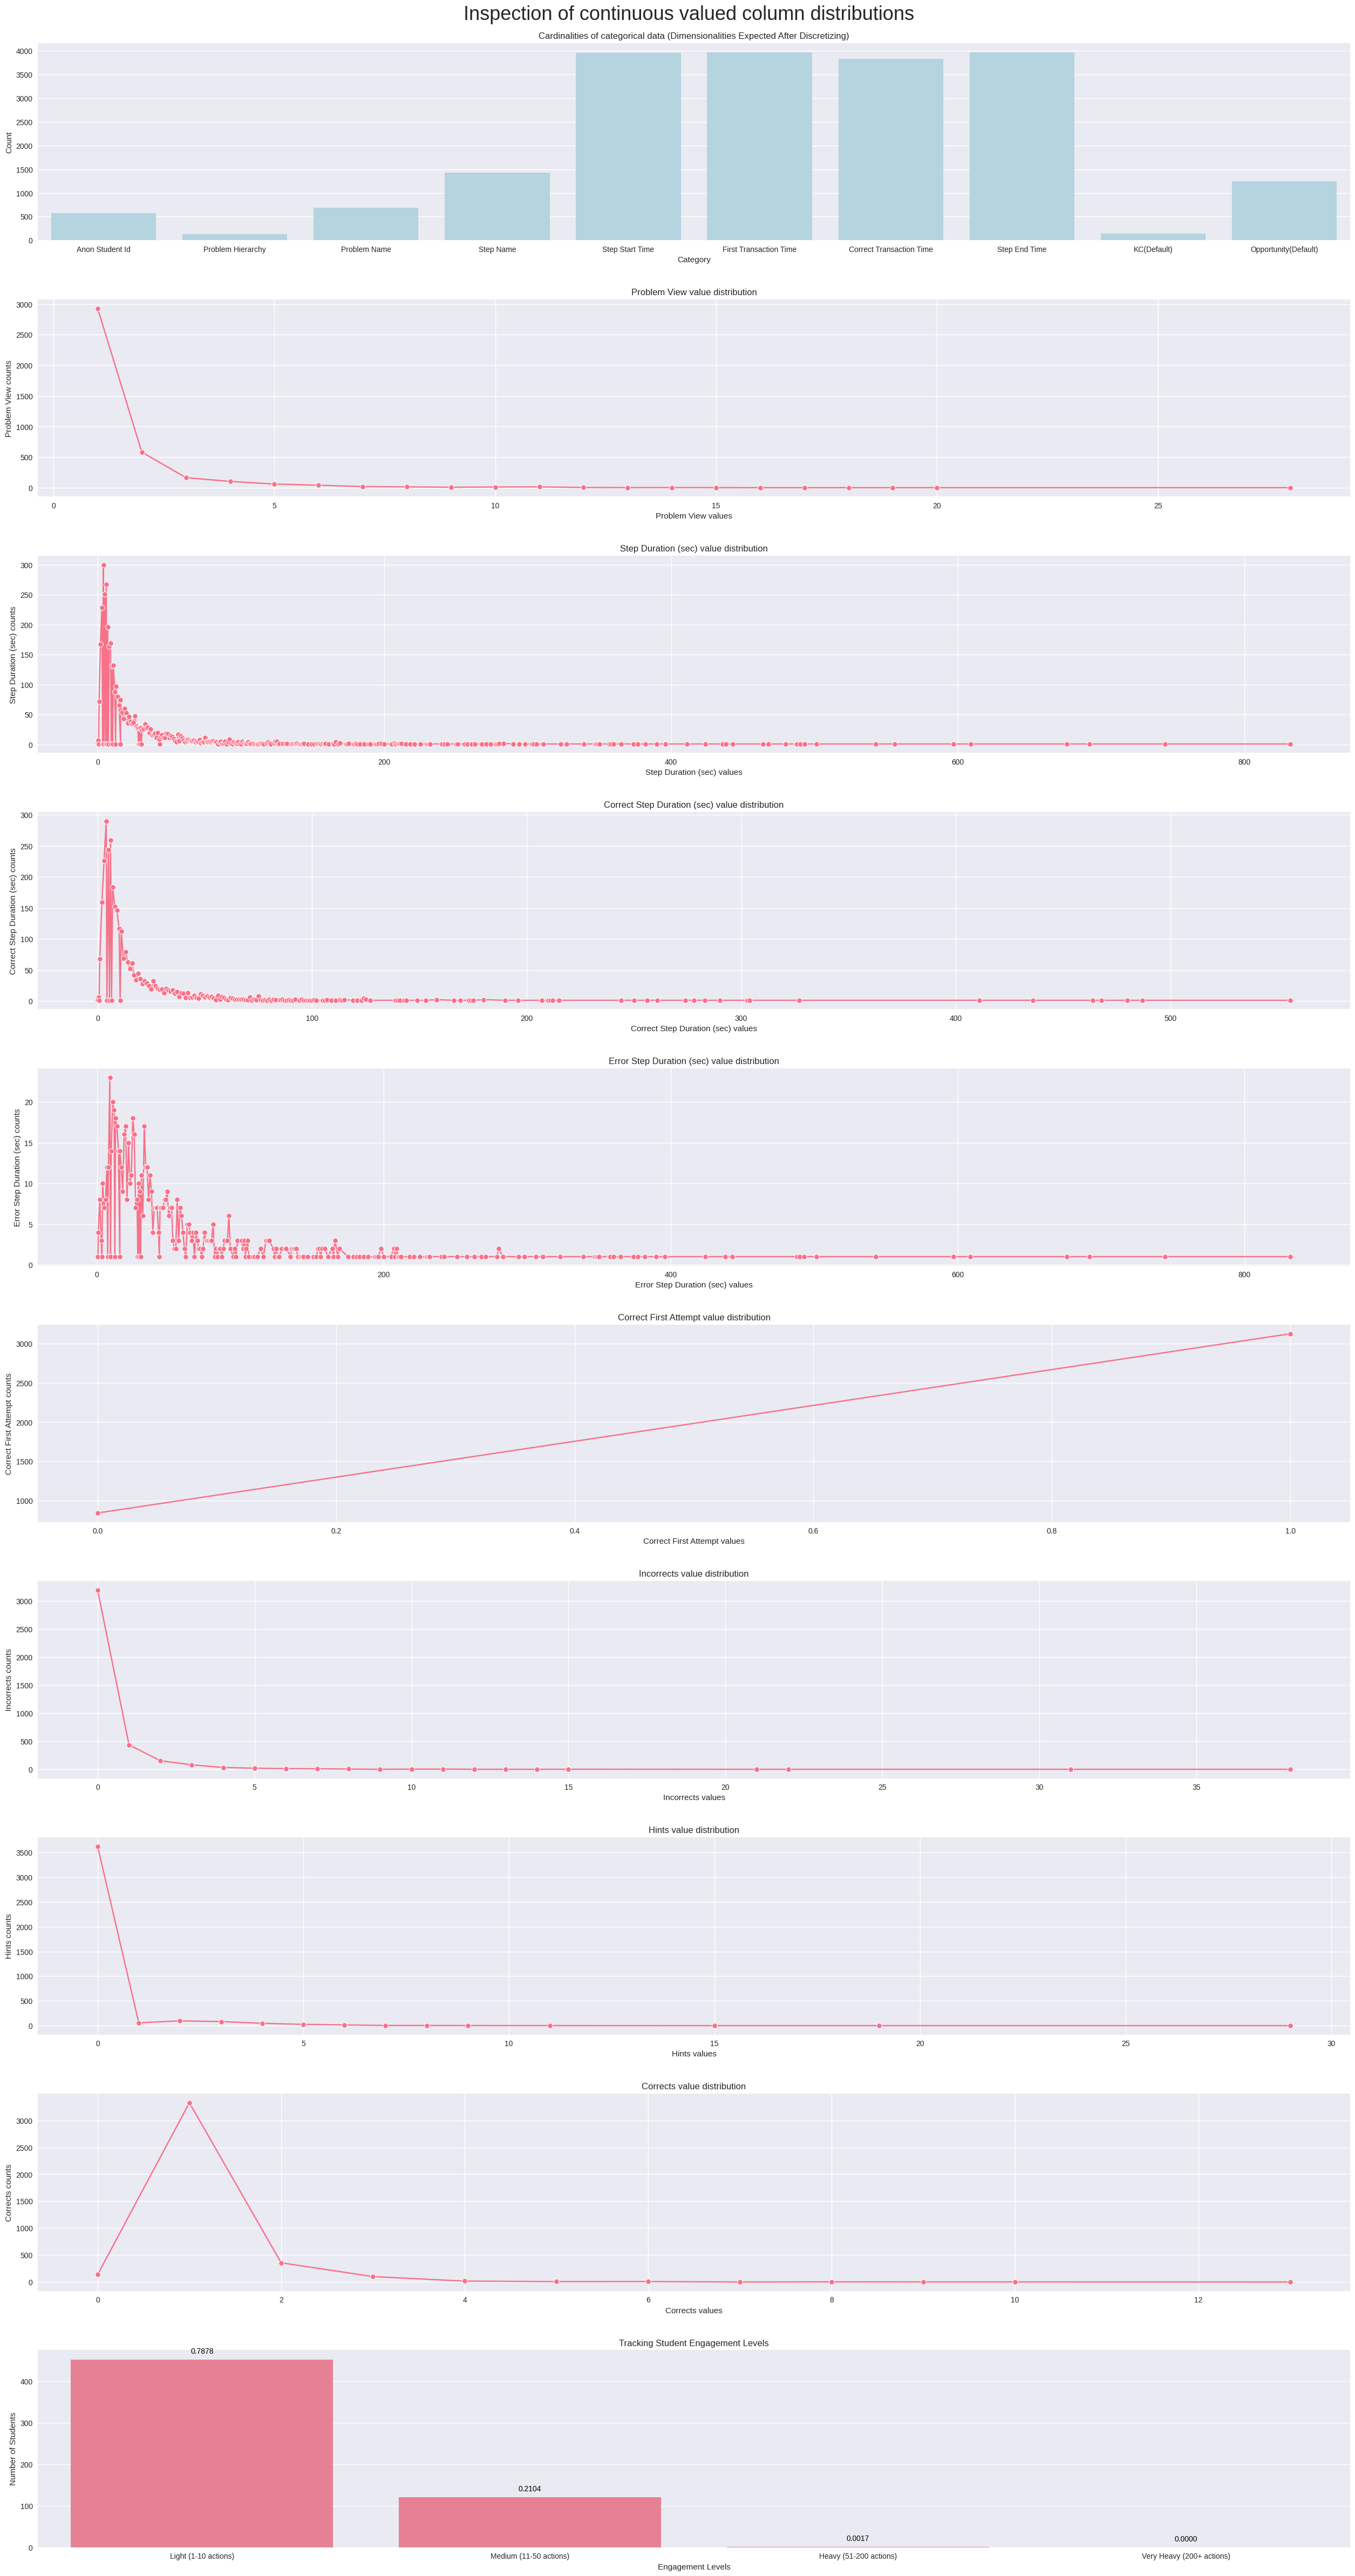

In [111]:
plot_all_cont(df)

In [112]:
def show_cat_plt(name, series, axes, i):
    # Show counts of all others
    """Show top value types of problem hierarchy to get"""
    COUNT = 40
    top_40 = series.value_counts().head(COUNT)

    ax = sns.barplot(x=top_40.index, y=top_40.values, color='lightblue', ax=axes[i])
    ax.set(
        title=f"Top {COUNT} categories in {name}",
        xlabel = f'{name} categories',
        ylabel = f'{name} counts',
        xticklabels=np.arange(len(top_40.index)-1)
    )

    total_counts = float(series.value_counts().sum())
    annotate_pcts(
        ax=ax,
        total=total_counts,
        data=top_40,
        index=top_40.index,
        values=top_40.values
    )

def plot_all_cat(df):
  """Plot for all continuous valued columns"""
  cat_cols = df.select_dtypes(include=["object"])
  print(cat_cols.columns)

  fig, axes = plt.subplots(len(cat_cols.columns)+2, 1, figsize=(25, 50))
  fig.tight_layout(rect=[0, 0.03, 1, 0.97])
  fig.subplots_adjust(hspace=0.3)
  fig.suptitle('Inspection of continuous valued column distributions', fontsize=26)

  i = 0
  show_cardinalities(df, axes, i)
  for name, series in cat_cols.items():
    i+=1
    show_cat_plt(name, series, axes, i)

  i+=1
  show_engagement_lvls(df, axes, i)

Index(['Anon Student Id', 'Problem Hierarchy', 'Problem Name', 'Step Name',
       'Step Start Time', 'First Transaction Time', 'Correct Transaction Time',
       'Step End Time', 'KC(Default)', 'Opportunity(Default)'],
      dtype='object')


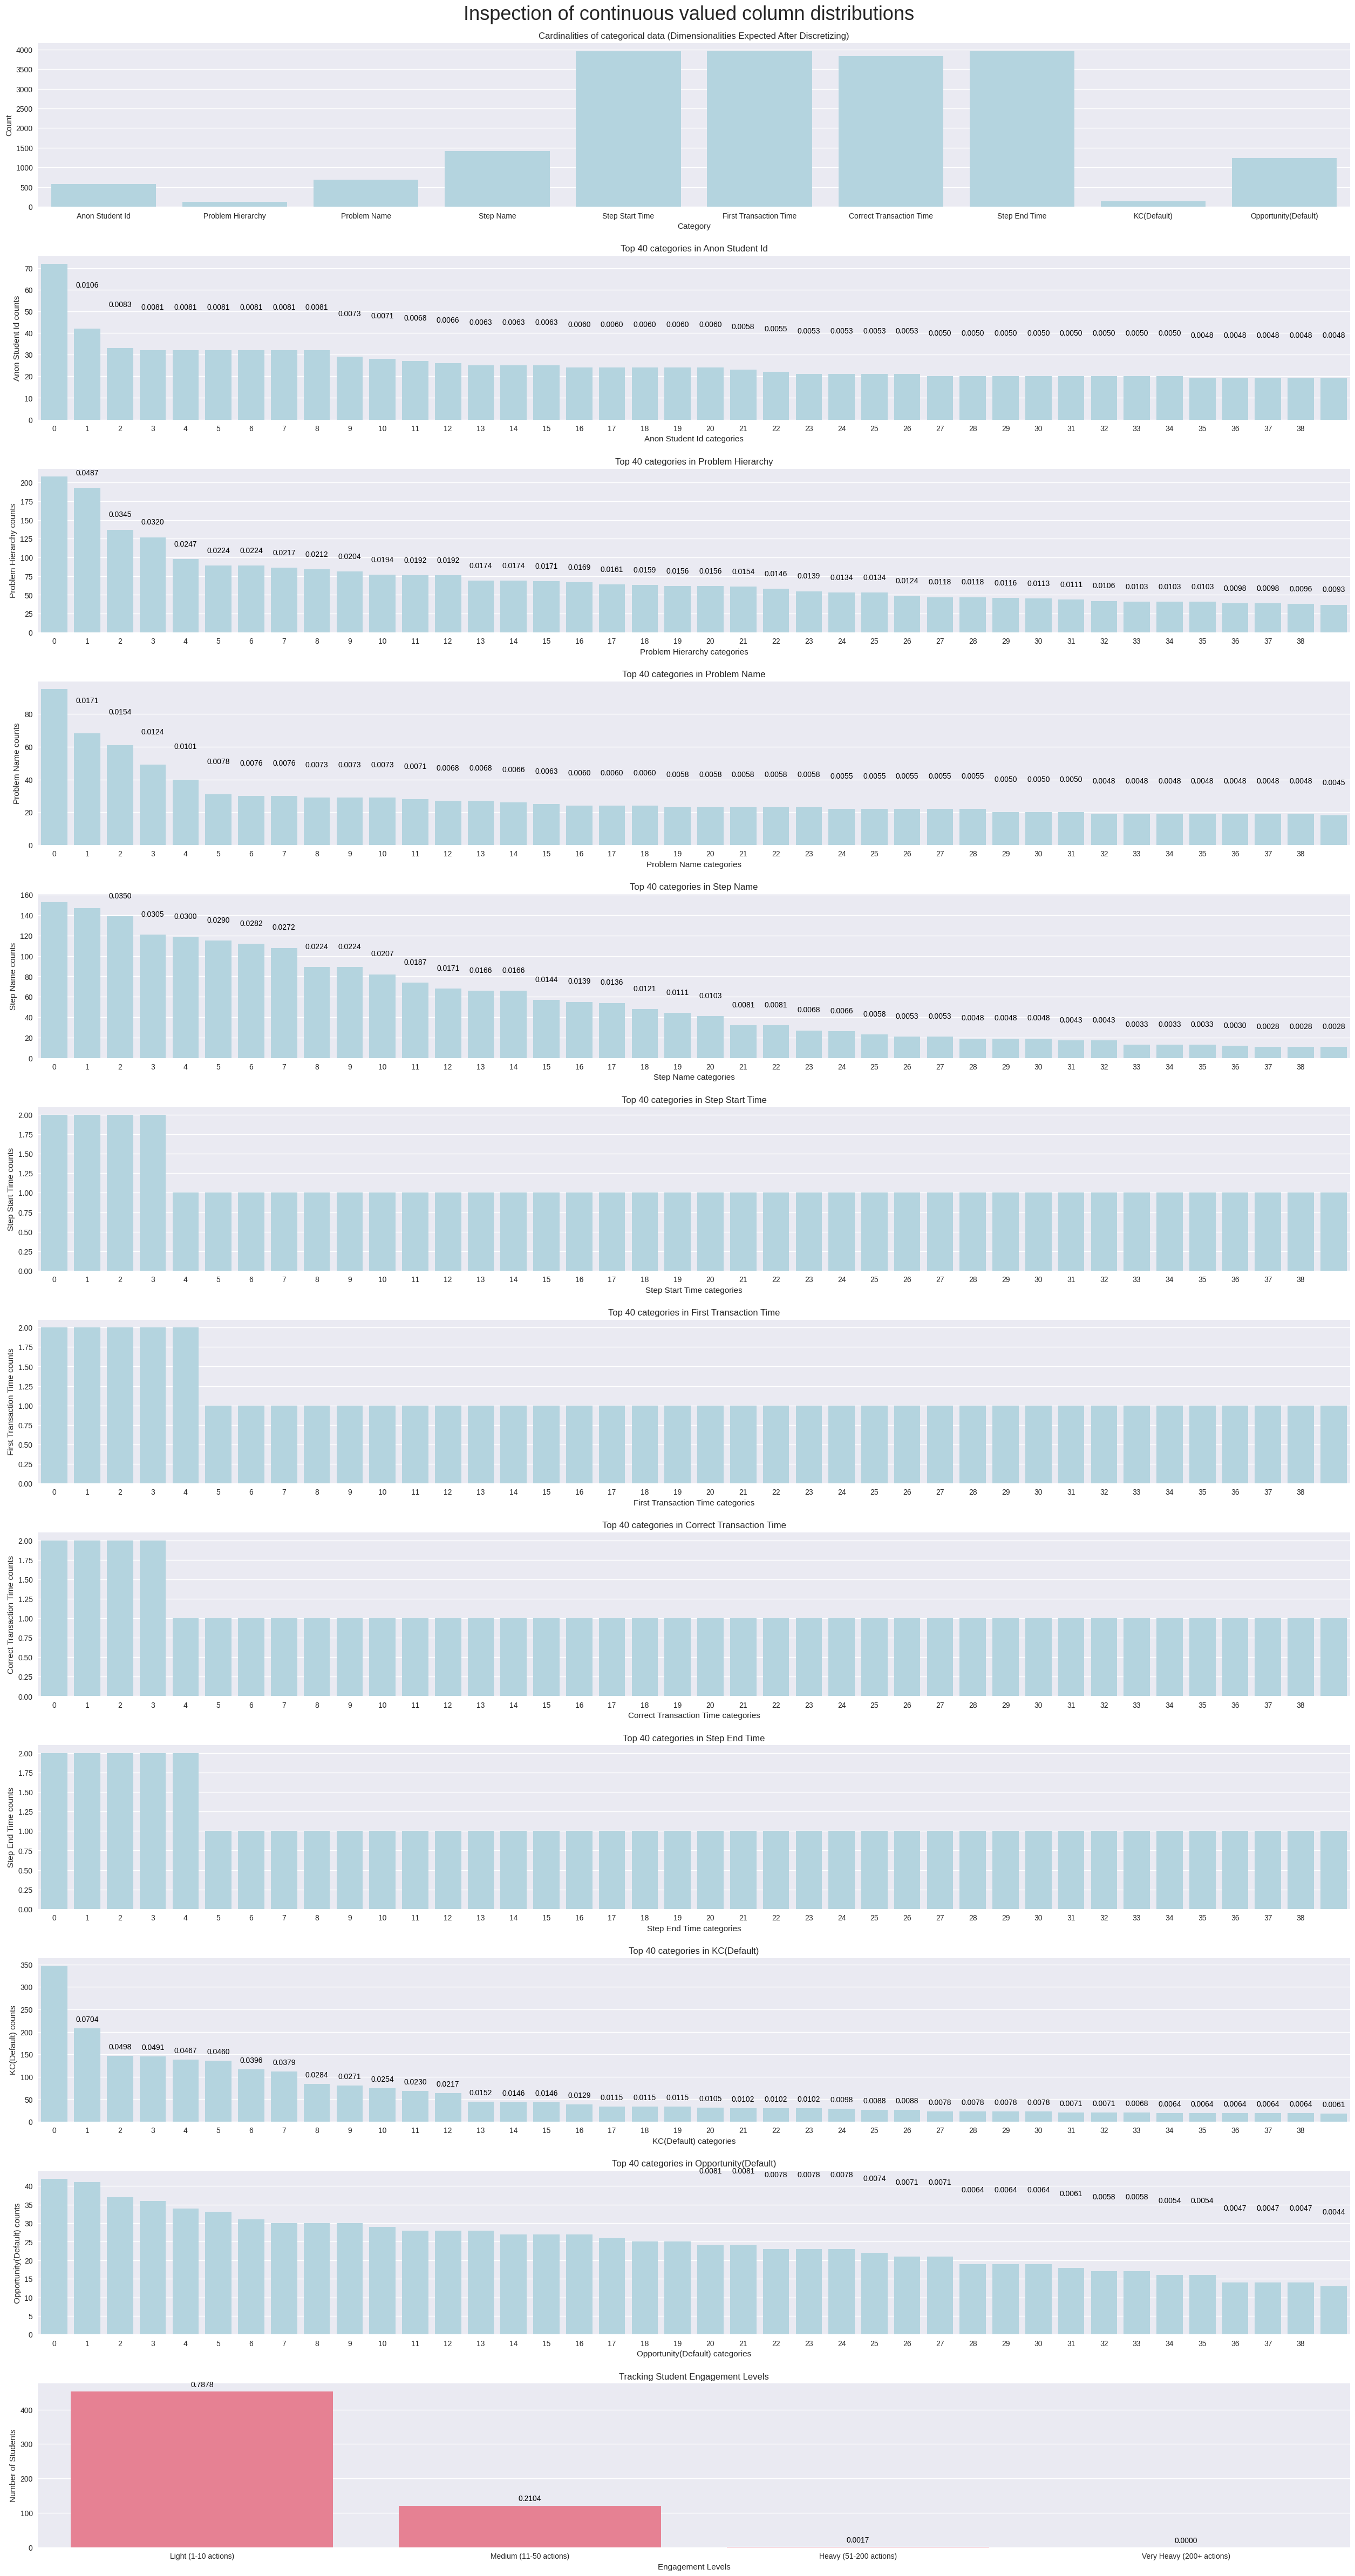

In [113]:
# TODO: Create plot for distribution/bar for all columns just to help assoc rule mining
plot_all_cat(df)

# Discussion

From research, seems uncovering relationships between items is done with Apriori. We therefore only do univariate analysis in our EDA, sufficient for decision makers to make decisions about items of interest, and further curiosity about correlation between items. In a product market context association rules for top sellers may be chosen. In our case it depends on the questions educators want to answer. Not only the top occuring values in continuous valued or categorical columns need to be given attention to. These are subjective questions and they make for subjective analysis.

The EDA visualizations are illustrative of the shallow analysis decision makers might start with. Apriori and FP-growth algorithms will uncover further interesting patterns/rule based correlations given a support threshold. In other words, they will perform a multi-variate analysis for us.

We can target intentionally, or aim to discover general rules that meet the support threshold set. We want unorthodox rules to emerge, and this will happen only with a strict support threshold, even between 2 columns that seem to correlate. If 2 columns correlate, then 1 value highly predicts the value of the other which would make it unsuitable for the discovery of patterns with a low or high support threshold.
The thing is 1 value might correlate with another, in the support threshold, you will always see them formed together in other words with no surprise. When one occurs, the other occurs. However if set intentionally, then 1 value you check if exists association with another arbitrary value, they might not be the values that correlate. So correlations are relevant only in "discovering" insights that are not insights, but are rather obvious and inevitable. **This motivates the use of either pair-plots, and/or tabular correlation analysis.**

We made a choice as well to reduce the size of the dataset and resultant bins.
An extremely wide dataset might be easy to index, it is much like a very long array, which may be no problem. This will be returned to after implementation.


# Preprocessing todo:
- Drop columns with time/date stamps. Unneeded. We have enough variety of other column types.
- This is an **innovation point and is therefore optional** for now. Add "Engagement Level" column. This tracks a running counter, every time a student with an ID engages in the course, this counter increases starting at 1. This tracks progress of students in course and this feature engineered column can be used to create associations of if higher engagement with the course leads to better results.
- Split KC column with "~~" seperator for different knowledge components into different pandas column per KC in the row (via pandas string/mapping/regex functions), then do binning so every knowledge component is represented, and there is a binary 1 or 0 to mark if a row had that knowledge component per row.

# EDA todo:

- After preprocessing KC column, do EDA on it, think what kind of EDA can be done on a multi-valued column.
- Perform correlation analysis/pair-plot to inform us what redundant rules to avoid between columns when we perform Apriori/FP-growth. We can also try confirm the redundancies.